# Bank Marketing: Kronolojik Yanıt Tahmini ve Temas Önceliklendirmesi

Bu çalışma, UCI Bank Marketing temas kayıtlarında olumlu yanıt eğilimi yüksek kayıtları sıralamak için hazırlanmış sade bir eğitim ve portföy projesidir.

**Temel soru:** Her kampanya döneminde yalnızca belirli sayıda kayıt işleme alınabiliyorsa, hangi kayıtlar önce değerlendirilmelidir?

### Ana metodoloji

- Dosyanın kronolojik sırası korunur.
- Tam ay blokları **training → validation → test** olarak ayrılır.
- Yalnızca **Logistic Regression** ve **Random Forest** karşılaştırılır.
- Model seçimi validation bölümündeki **Lift@20** sonucuna göre yapılır; PR-AUC destek metriğidir.
- Seçilen model training ve validation birleştirilerek yeniden eğitilir ve en güncel test bölümünde yalnızca bir kez değerlendirilir.
- Kapasite hesapları her kampanya dönemi içinde ayrı sıralama yapılarak oluşturulur.

Bu çalışma gerçek banka verisi, canlı CRM sistemi veya production model raporu değildir.

## 1. Kütüphaneler, proje yolları ve sabit kararlar

Model sayısı ve ayarlar bilinçli olarak sınırlı tutulmuştur. Kapsamlı hiperparametre optimizasyonu yapılmamış; açıklanabilir bir baseline ile kontrollü bir ağaç modeli karşılaştırılmıştır.

In [1]:
from pathlib import Path
import platform

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

candidate_roots = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(
    (root for root in candidate_roots if (root / "data" / "bank-additional-full.csv").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "data/bank-additional-full.csv bulunamadı. Proje klasör yapısını koruyarak notebook'u çalıştırın."
    )

DATA_PATH = PROJECT_ROOT / "data" / "bank-additional-full.csv"
METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
POWERBI_DIR = PROJECT_ROOT / "outputs" / "powerbi"
METRICS_DIR.mkdir(parents=True, exist_ok=True)
POWERBI_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
CLASSIFICATION_THRESHOLD = 0.50
TOP_K_RATE = 0.20
CAPACITY_RATES = (0.05, 0.10, 0.20, 0.30, 0.40, 0.50)

# Tam dönem blokları: training 1–8, validation 9–10, test 11–26.
TRAIN_PERIOD_END = 8
VALIDATION_PERIOD_END = 10

print(f"Python: {platform.python_version()}")
print(f"Proje kökü: {PROJECT_ROOT.resolve()}")
print(f"Veri: {DATA_PATH.resolve()}")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-n2hg3g1h because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Python: 3.13.5
Proje kökü: /mnt/data/Efe_Catikkas_Bank_Marketing_Kronolojik_v3
Veri: /mnt/data/Efe_Catikkas_Bank_Marketing_Kronolojik_v3/data/bank-additional-full.csv


## 2. Veri yükleme, kalite kontrolleri ve kampanya dönemleri

Veri setinde güvenilir müşteri kimliği bulunmadığı için her satır **kampanya temas kaydı** olarak değerlendirilir. Tam duplicate satırlar, birebir aynı gözlemin farklı veri bölümlerine düşmesini önlemek amacıyla modelleme öncesinde çıkarılır.

Dosya kronolojik sırada olduğu için, ay değiştiğinde yeni bir `campaign_period_id` oluşturulur. Bu teknik alan yalnızca kronolojik ayrım ve dönem içi kapasite hesabında kullanılır; modele verilmez.

In [2]:
REQUIRED_COLUMNS = {
    "age", "job", "marital", "education", "default", "housing", "loan",
    "contact", "month", "day_of_week", "duration", "campaign", "pdays",
    "previous", "poutcome", "emp.var.rate", "cons.price.idx",
    "cons.conf.idx", "euribor3m", "nr.employed", "y",
}

raw_df = pd.read_csv(DATA_PATH, sep=";")
missing_columns = REQUIRED_COLUMNS.difference(raw_df.columns)
if missing_columns:
    raise ValueError(f"Eksik sütunlar: {sorted(missing_columns)}")

raw_record_count = len(raw_df)
exact_duplicate_count = int(raw_df.duplicated().sum())

df = raw_df.drop_duplicates().reset_index(drop=True).copy()
df.insert(0, "record_id", np.arange(1, len(df) + 1))
df["y_binary"] = df["y"].map({"no": 0, "yes": 1}).astype(int)
df["previously_contacted"] = np.where(df["pdays"].eq(999), "no", "yes")
df["campaign_period_id"] = df["month"].ne(df["month"].shift()).cumsum().astype(int)

quality_summary = pd.DataFrame({
    "metric": [
        "Ham kayıt sayısı",
        "Tam duplicate satır",
        "Modelleme kayıt sayısı",
        "Olumlu kayıt",
        "Olumsuz kayıt",
        "Olumlu yanıt oranı",
        "Unknown içeren hücre",
        "Kampanya dönem bloğu",
    ],
    "value": [
        raw_record_count,
        exact_duplicate_count,
        len(df),
        int(df["y_binary"].sum()),
        int((1 - df["y_binary"]).sum()),
        df["y_binary"].mean(),
        int(df.astype(str).eq("unknown").sum().sum()),
        int(df["campaign_period_id"].nunique()),
    ],
})

period_summary = (
    df.groupby(["campaign_period_id", "month"], as_index=False, observed=True)
      .agg(
          record_count=("record_id", "size"),
          positive_count=("y_binary", "sum"),
          positive_rate=("y_binary", "mean"),
      )
)

display(quality_summary)
display(period_summary)

,metric,value
0,Ham kayıt sayısı,41188.000000
1,Tam duplicate satır,12.000000
2,Modelleme kayıt sayısı,41176.000000
3,Olumlu kayıt,4639.000000
4,Olumsuz kayıt,36537.000000
5,Olumlu yanıt oranı,0.112663
6,Unknown içeren hücre,12716.000000
7,Kampanya dönem bloğu,26.000000


,campaign_period_id,month,record_count,positive_count,positive_rate
0,1,may,7762,240,0.030920
1,2,jun,4374,188,0.042981
2,3,jul,6681,407,0.060919
3,4,aug,5173,271,0.052387
4,5,oct,67,42,0.626866
5,6,nov,3615,190,0.052559
6,7,dec,10,1,0.100000
7,8,mar,282,126,0.446809
8,9,apr,2457,442,0.179894
9,10,may,5793,524,0.090454


## 3. Kısa keşifsel analiz

Bu bölüm modelden önce hedef dağılımını, `unknown` değerlerini, temel sayısal alanları ve kampanya dönemleri arasındaki yanıt oranı değişimini görünür hale getirir.

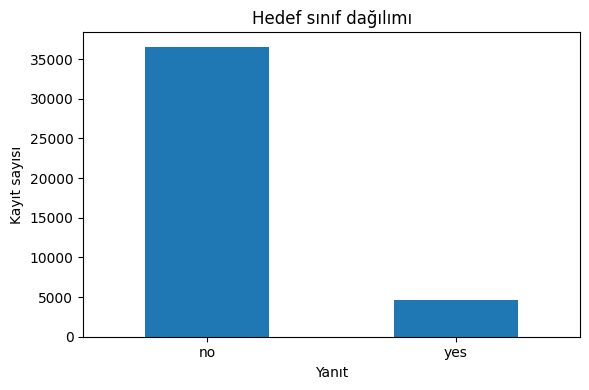

,column,unknown_count,unknown_rate
0,default,8596,0.208762
1,education,1730,0.042015
2,housing,990,0.024043
3,loan,990,0.024043
4,job,330,0.008014
5,marital,80,0.001943
6,contact,0,0.000000
7,month,0,0.000000
8,day_of_week,0,0.000000
9,poutcome,0,0.000000


,count,mean,std,min,25%,50%,75%,max,median
age,41176.0,40.023800,10.420680,17.0,32.0,38.0,47.0,98.0,38.0
campaign,41176.0,2.567879,2.770318,1.0,1.0,2.0,3.0,56.0,2.0
previous,41176.0,0.173013,0.494964,0.0,0.0,0.0,0.0,7.0,0.0


### `poutcome` kırılımı

,record_count,response_rate
poutcome,,
success,1373,0.651129
failure,4252,0.142286
nonexistent,35551,0.088324


### `contact` kırılımı

,record_count,response_rate
contact,,
cellular,26135,0.147389
telephone,15041,0.052324


### `previously_contacted` kırılımı

,record_count,response_rate
previously_contacted,,
yes,1515,0.638284
no,39661,0.092585


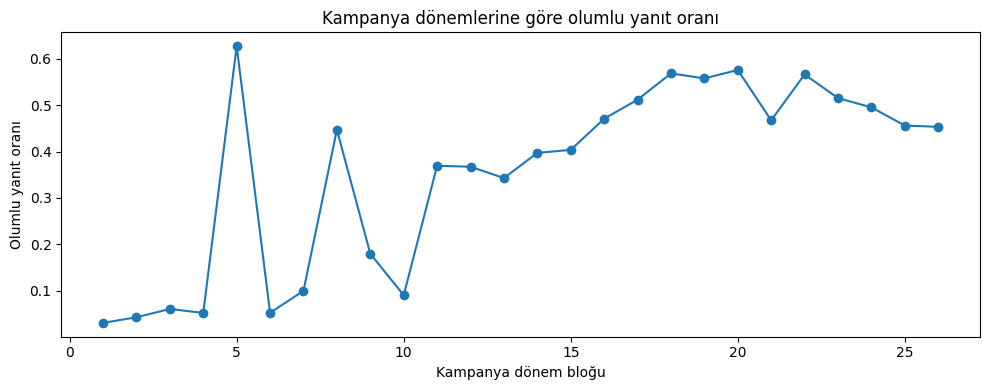

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
df["y"].value_counts().reindex(["no", "yes"]).plot(kind="bar", ax=ax)
ax.set_title("Hedef sınıf dağılımı")
ax.set_xlabel("Yanıt")
ax.set_ylabel("Kayıt sayısı")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

categorical_columns = [
    "job", "marital", "education", "default", "housing", "loan",
    "contact", "month", "day_of_week", "poutcome",
]
unknown_summary = pd.DataFrame({
    "column": categorical_columns,
    "unknown_count": [int(df[column].eq("unknown").sum()) for column in categorical_columns],
})
unknown_summary["unknown_rate"] = unknown_summary["unknown_count"] / len(df)
unknown_summary = unknown_summary.sort_values("unknown_count", ascending=False).reset_index(drop=True)
display(unknown_summary)

numeric_profile = df[["age", "campaign", "previous"]].describe().T
numeric_profile["median"] = df[["age", "campaign", "previous"]].median()
display(numeric_profile)

profile_tables = {}
for column in ["poutcome", "contact", "previously_contacted"]:
    profile_tables[column] = (
        df.groupby(column, observed=True)
          .agg(record_count=("record_id", "size"), response_rate=("y_binary", "mean"))
          .sort_values("response_rate", ascending=False)
    )
    display(Markdown(f"### `{column}` kırılımı"))
    display(profile_tables[column])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(period_summary["campaign_period_id"], period_summary["positive_rate"], marker="o")
ax.set_title("Kampanya dönemlerine göre olumlu yanıt oranı")
ax.set_xlabel("Kampanya dönem bloğu")
ax.set_ylabel("Olumlu yanıt oranı")
plt.tight_layout()
plt.show()

## 4. Tahmin anı, feature politikası ve kronolojik ayrım

Model, kampanyadan aylar önce müşteri seçen bir sistem olarak değil; planlanmış temas girişiminden hemen önce kayıtları sıralayan retrospektif bir örnek olarak yorumlanır.

- `duration`: görüşme tamamlandıktan sonra oluştuğu için leakage.
- `pdays`: `999` sentinel değeri ve eksik zaman bağlamı nedeniyle kullanılmaz.
- Makroekonomik alanlar: dönem koşullarını güçlü biçimde temsil edebileceği ve farklı döneme taşınabilirliği azaltabileceği için ana modelden çıkarılır.
- `campaign`, `contact`, `month`, `day_of_week`: planlanan temas anında bilindiği varsayılan koşullu alanlardır.

In [4]:
NUMERIC_FEATURES = ["age", "campaign", "previous"]
CATEGORICAL_FEATURES = [
    "job", "marital", "education", "default", "housing", "loan",
    "contact", "month", "day_of_week", "poutcome", "previously_contacted",
]
MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

EXCLUDED_FEATURES = pd.DataFrame([
    {"feature": "duration", "reason": "Görüşme sonrasında oluşur; tahmin anında bilinmez."},
    {"feature": "pdays", "reason": "999 sentinel değeri ve tam zaman bilgisinin belirsizliği."},
    {"feature": "emp.var.rate", "reason": "Makroekonomik dönem vekili ve taşınabilirlik riski."},
    {"feature": "cons.price.idx", "reason": "Makroekonomik dönem vekili ve taşınabilirlik riski."},
    {"feature": "cons.conf.idx", "reason": "Makroekonomik dönem vekili ve taşınabilirlik riski."},
    {"feature": "euribor3m", "reason": "Makroekonomik dönem vekili ve taşınabilirlik riski."},
    {"feature": "nr.employed", "reason": "Makroekonomik dönem vekili ve taşınabilirlik riski."},
])

train_df = df.loc[df["campaign_period_id"].le(TRAIN_PERIOD_END)].copy()
validation_df = df.loc[
    df["campaign_period_id"].gt(TRAIN_PERIOD_END)
    & df["campaign_period_id"].le(VALIDATION_PERIOD_END)
].copy()
test_df = df.loc[df["campaign_period_id"].gt(VALIDATION_PERIOD_END)].copy()

if not (
    train_df["campaign_period_id"].max() < validation_df["campaign_period_id"].min()
    and validation_df["campaign_period_id"].max() < test_df["campaign_period_id"].min()
):
    raise AssertionError("Kronolojik split sırası bozuldu.")

split_summary = pd.DataFrame([
    {
        "split": "Training",
        "period_start": int(train_df["campaign_period_id"].min()),
        "period_end": int(train_df["campaign_period_id"].max()),
        "record_count": len(train_df),
        "positive_count": int(train_df["y_binary"].sum()),
        "positive_rate": train_df["y_binary"].mean(),
    },
    {
        "split": "Validation",
        "period_start": int(validation_df["campaign_period_id"].min()),
        "period_end": int(validation_df["campaign_period_id"].max()),
        "record_count": len(validation_df),
        "positive_count": int(validation_df["y_binary"].sum()),
        "positive_rate": validation_df["y_binary"].mean(),
    },
    {
        "split": "Test",
        "period_start": int(test_df["campaign_period_id"].min()),
        "period_end": int(test_df["campaign_period_id"].max()),
        "record_count": len(test_df),
        "positive_count": int(test_df["y_binary"].sum()),
        "positive_rate": test_df["y_binary"].mean(),
    },
])

display(pd.DataFrame({"model_feature": MODEL_FEATURES}))
display(EXCLUDED_FEATURES)
display(split_summary)

,model_feature
0,age
1,campaign
2,previous
3,job
4,marital
5,education
6,default
7,housing
8,loan
9,contact


,feature,reason
0,duration,Görüşme sonrasında oluşur; tahmin anında bilin...
1,pdays,999 sentinel değeri ve tam zaman bilgisinin be...
2,emp.var.rate,Makroekonomik dönem vekili ve taşınabilirlik r...
3,cons.price.idx,Makroekonomik dönem vekili ve taşınabilirlik r...
4,cons.conf.idx,Makroekonomik dönem vekili ve taşınabilirlik r...
5,euribor3m,Makroekonomik dönem vekili ve taşınabilirlik r...
6,nr.employed,Makroekonomik dönem vekili ve taşınabilirlik r...


,split,period_start,period_end,record_count,positive_count,positive_rate
0,Training,1,8,27964,1465,0.052389
1,Validation,9,10,8250,966,0.117091
2,Test,11,26,4962,2208,0.444982


## 5. Pipeline, iki model ve dönem içi kapasite fonksiyonları

- **Logistic Regression:** açıklanabilir baseline.
- **Random Forest:** doğrusal olmayan ilişkileri yakalayabilen challenger.

Ayarlar kapsamlı tuning sonucu değildir. Aşırı karmaşıklığı sınırlayan tek bir manuel yapılandırma kullanılır ve optimum olduğu iddia edilmez.

In [5]:
def make_preprocessor(scale_numeric: bool) -> ColumnTransformer:
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, NUMERIC_FEATURES),
        ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
    ])

MODEL_TEMPLATES = {
    "Logistic Regression": Pipeline([
        ("preprocessor", make_preprocessor(scale_numeric=True)),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", make_preprocessor(scale_numeric=False)),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            min_samples_leaf=10,
            class_weight="balanced_subsample",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ]),
}


def build_period_capacity_table(evaluation_df: pd.DataFrame, scores, capacity_rates) -> pd.DataFrame:
    """Her kampanya döneminde kayıtları ayrı sıralar ve toplam kapasite metriklerini üretir."""
    scored = evaluation_df[["record_id", "campaign_period_id", "y_binary"]].copy()
    scored["response_score"] = np.asarray(scores)

    rows = []
    for rate in capacity_rates:
        selected_indices = []
        expected_random_positive = 0.0

        for _, period_group in scored.groupby("campaign_period_id", sort=True):
            selected_n = max(1, int(np.ceil(rate * len(period_group))))
            selected_period = (
                period_group.sort_values(
                    ["response_score", "record_id"],
                    ascending=[False, True],
                    kind="mergesort",
                )
                .head(selected_n)
            )
            selected_indices.extend(selected_period.index.tolist())
            expected_random_positive += selected_n * period_group["y_binary"].mean()

        selected = scored.loc[selected_indices]
        base_rate = scored["y_binary"].mean()
        response_rate = selected["y_binary"].mean()
        selected_positive = int(selected["y_binary"].sum())

        rows.append({
            "capacity_rate": rate,
            "selected_count": int(len(selected)),
            "selected_positive": selected_positive,
            "base_rate": base_rate,
            "response_rate": response_rate,
            "capture": selected_positive / scored["y_binary"].sum(),
            "lift": response_rate / base_rate,
            "expected_random_positive": expected_random_positive,
            "expected_extra_positive": selected_positive - expected_random_positive,
        })

    return pd.DataFrame(rows)


def evaluate_pipeline(model_name: str, pipeline: Pipeline, fit_df: pd.DataFrame, evaluation_df: pd.DataFrame):
    fitted = clone(pipeline)
    fitted.fit(fit_df[MODEL_FEATURES], fit_df["y_binary"])

    scores = fitted.predict_proba(evaluation_df[MODEL_FEATURES])[:, 1]
    predictions = (scores >= CLASSIFICATION_THRESHOLD).astype(int)
    capacity_20 = build_period_capacity_table(evaluation_df, scores, [TOP_K_RATE]).iloc[0]

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(evaluation_df["y_binary"], predictions),
        "precision": precision_score(evaluation_df["y_binary"], predictions, zero_division=0),
        "recall": recall_score(evaluation_df["y_binary"], predictions, zero_division=0),
        "f1": f1_score(evaluation_df["y_binary"], predictions, zero_division=0),
        "roc_auc": roc_auc_score(evaluation_df["y_binary"], scores),
        "pr_auc": average_precision_score(evaluation_df["y_binary"], scores),
        "selected_count_at_20": int(capacity_20["selected_count"]),
        "response_rate_at_20": capacity_20["response_rate"],
        "capture_at_20": capacity_20["capture"],
        "lift_at_20": capacity_20["lift"],
        "expected_extra_positive_at_20": capacity_20["expected_extra_positive"],
    }
    return fitted, scores, predictions, metrics

## 6. Validation bölümünde model karşılaştırması ve seçim

Birincil seçim ölçütü **Lift@20**'dir. Lift sonuçları yakınsa PR-AUC destek metriği olarak kullanılır. Test bölümü model seçimine dahil edilmez.

,evaluation_set,model,accuracy,precision,recall,f1,roc_auc,pr_auc,selected_count_at_20,response_rate_at_20,capture_at_20,lift_at_20,expected_extra_positive_at_20
0,Validation,Random Forest,0.7647,0.2061,0.3540,0.2606,0.6342,0.1993,1651,0.1660,0.2836,1.4174,80.6559
1,Validation,Logistic Regression,0.6708,0.1818,0.5176,0.2691,0.6398,0.1946,1651,0.1599,0.2733,1.3656,70.6559


Seçilen model: Random Forest
İlk iki model arasındaki validation Lift@20 farkı: 0.0517


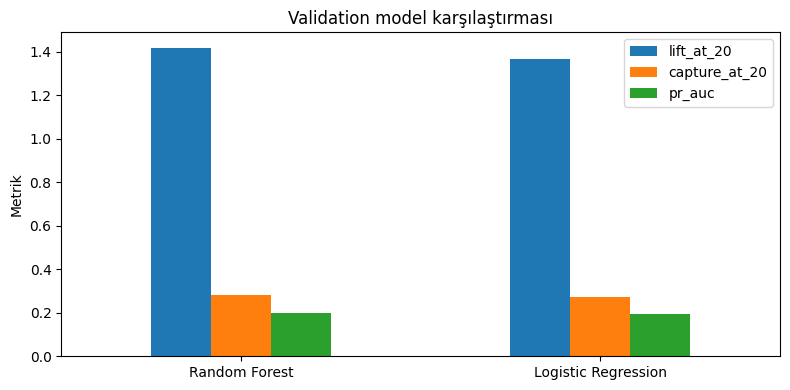

In [6]:
validation_models = {}
validation_scores = {}
comparison_rows = []

for model_name, template in MODEL_TEMPLATES.items():
    fitted, scores, predictions, metrics = evaluate_pipeline(
        model_name=model_name,
        pipeline=template,
        fit_df=train_df,
        evaluation_df=validation_df,
    )
    validation_models[model_name] = fitted
    validation_scores[model_name] = scores
    comparison_rows.append(metrics)

model_comparison = (
    pd.DataFrame(comparison_rows)
      .sort_values(["lift_at_20", "pr_auc"], ascending=False)
      .reset_index(drop=True)
)
model_comparison.insert(0, "evaluation_set", "Validation")

display(model_comparison.round(4))

SELECTED_MODEL_NAME = model_comparison.loc[0, "model"]
SELECTED_VALIDATION_MODEL = validation_models[SELECTED_MODEL_NAME]
SELECTED_VALIDATION_SCORES = validation_scores[SELECTED_MODEL_NAME]

lift_gap = model_comparison.loc[0, "lift_at_20"] - model_comparison.loc[1, "lift_at_20"]
print(f"Seçilen model: {SELECTED_MODEL_NAME}")
print(f"İlk iki model arasındaki validation Lift@20 farkı: {lift_gap:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
model_comparison.set_index("model")[["lift_at_20", "capture_at_20", "pr_auc"]].plot(kind="bar", ax=ax)
ax.set_title("Validation model karşılaştırması")
ax.set_xlabel("")
ax.set_ylabel("Metrik")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 7. Validation üzerinde standart permutation importance

Özellik önemleri final test kullanılmadan, seçilen modelin validation performansı üzerinden hesaplanır. Permutation importance bir alanın değerleri karıştırıldığında PR-AUC'nin ortalama ne kadar değiştiğini gösterir; nedensellik değildir.

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 785, in warm_spreadsheet_runtime
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 720, in _warm_feature_flows
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 704, in _warm_collaboration_flows
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/generated/interface/models.py", line 30820, in hydrate_crdt_from_proto
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/rpc/remote.py", line 749, in __call__
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/rpc/client.py", line 150, in call
artifact_tool.rpc.client.RemoteE

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 785, in warm_spreadsheet_runtime
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 720, in _warm_feature_flows
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 704, in _warm_collaboration_flows
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/generated/interface/models.py", line 30820, in hydrate_crdt_from_proto
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/rpc/remote.py", line 749, in __call__
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/rpc/client.py", line 150, in call
artifact_tool.rpc.client.RemoteE

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 785, in warm_spreadsheet_runtime
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 720, in _warm_feature_flows
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 704, in _warm_collaboration_flows
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/generated/interface/models.py", line 30820, in hydrate_crdt_from_proto
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/rpc/remote.py", line 749, in __call__
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/rpc/client.py", line 150, in call
artifact_tool.rpc.client.RemoteE

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 785, in warm_spreadsheet_runtime
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 720, in _warm_feature_flows
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 704, in _warm_collaboration_flows
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/generated/interface/models.py", line 30820, in hydrate_crdt_from_proto
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/rpc/remote.py", line 749, in __call__
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/rpc/client.py", line 150, in call
artifact_tool.rpc.client.RemoteE

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 785, in warm_spreadsheet_runtime
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 720, in _warm_feature_flows
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 704, in _warm_collaboration_flows
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/generated/interface/models.py", line 30820, in hydrate_crdt_from_proto
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/rpc/remote.py", line 749, in __call__
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/rpc/client.py", line 150, in call
artifact_tool.rpc.client.RemoteE

Spreadsheet runtime warmup failed during python startup
Traceback (most recent call last):
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/patches/warm_spreadsheet_runtime_on_startup.py", line 26, in warm_spreadsheet_runtime_on_startup
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 785, in warm_spreadsheet_runtime
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 720, in _warm_feature_flows
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/spreadsheet_warmup.py", line 704, in _warm_collaboration_flows
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/generated/interface/models.py", line 30820, in hydrate_crdt_from_proto
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/rpc/remote.py", line 749, in __call__
  File "/tmp/tmp.yTcnQsZYiA/artifact_tool_v2-2.8.4/artifact_tool/rpc/client.py", line 150, in call
artifact_tool.rpc.client.RemoteE

,feature,importance_mean,importance_std,scoring,evaluation_set
0,month,0.0490,0.0037,average_precision,Validation
1,age,0.0175,0.0026,average_precision,Validation
2,poutcome,0.0143,0.0040,average_precision,Validation
3,default,0.0075,0.0021,average_precision,Validation
4,job,0.0064,0.0020,average_precision,Validation
5,education,0.0056,0.0036,average_precision,Validation
6,previously_contacted,0.0048,0.0007,average_precision,Validation
7,contact,0.0030,0.0032,average_precision,Validation
8,previous,0.0016,0.0027,average_precision,Validation
9,marital,0.0011,0.0022,average_precision,Validation


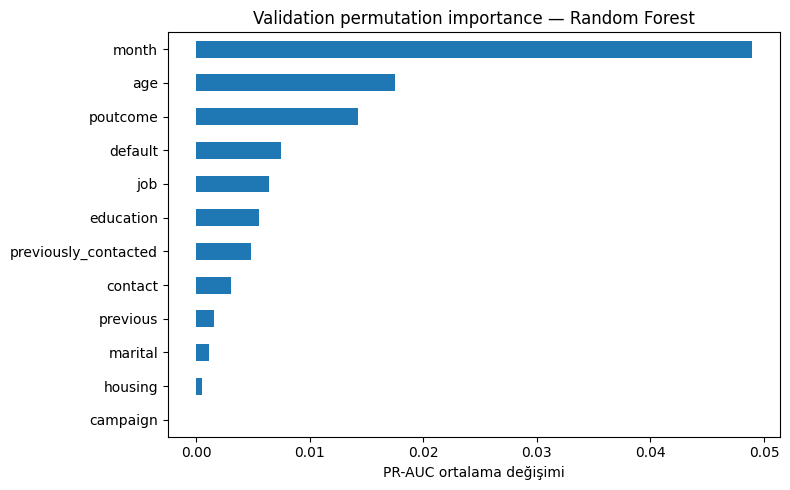

In [7]:
permutation_result = permutation_importance(
    SELECTED_VALIDATION_MODEL,
    validation_df[MODEL_FEATURES],
    validation_df["y_binary"],
    scoring="average_precision",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

feature_importance = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std,
    "scoring": "average_precision",
    "evaluation_set": "Validation",
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

display(feature_importance.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
feature_importance.head(12).sort_values("importance_mean").plot(
    kind="barh", x="feature", y="importance_mean", legend=False, ax=ax
)
ax.set_title(f"Validation permutation importance — {SELECTED_MODEL_NAME}")
ax.set_xlabel("PR-AUC ortalama değişimi")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 8. Seçilen modelin untouched test değerlendirmesi

Seçilen model, training ve validation verileri birleştirilerek yeniden eğitilir. En güncel test dönemi bu aşamaya kadar model seçimi veya feature kararı için kullanılmamıştır.

,value
selected_model,Random Forest
evaluation_set,Untouched chronological test
test_record_count,4962
test_positive_rate,0.444982
accuracy,0.573559
majority_baseline_accuracy,0.555018
precision,0.513618
recall,0.785779
f1,0.621196
roc_auc,0.6601


,capacity_rate,selected_count,selected_positive,base_rate,response_rate,capture,lift,expected_random_positive,expected_extra_positive
0,0.05,256,179,0.445,0.6992,0.0811,1.5713,114.1359,64.8641
1,0.10,504,356,0.445,0.7063,0.1612,1.5874,224.6888,131.3112
2,0.20,999,678,0.445,0.6787,0.3071,1.5252,444.7638,233.2362
3,0.30,1497,937,0.445,0.6259,0.4244,1.4066,666.3859,270.6141
4,0.40,1991,1150,0.445,0.5776,0.5208,1.2980,886.2362,263.7638
5,0.50,2485,1342,0.445,0.5400,0.6078,1.2136,1105.8236,236.1764


,Tahmin Olumsuz,Tahmin Olumlu
Gerçek Olumsuz,1111,1643
Gerçek Olumlu,473,1735


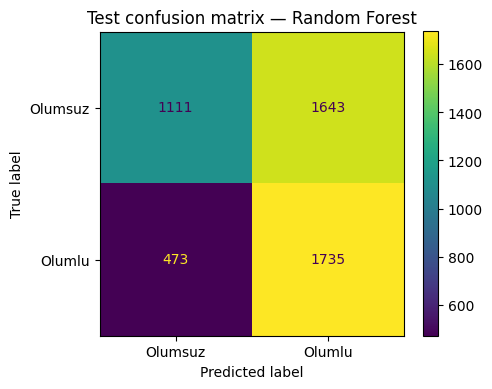

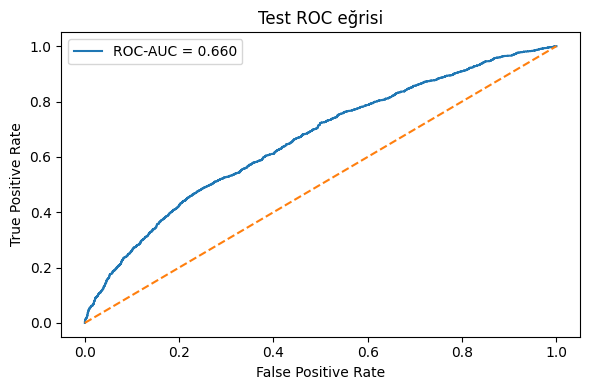

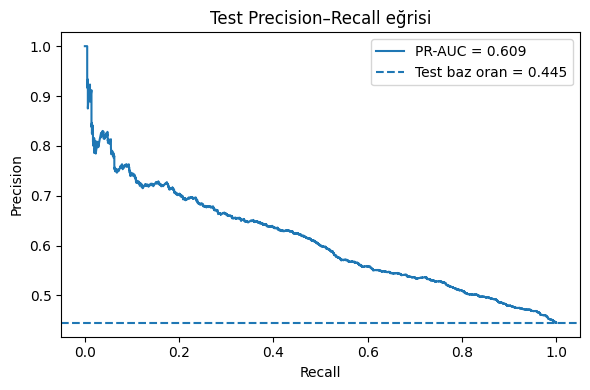

In [8]:
train_validation_df = pd.concat([train_df, validation_df], axis=0).sort_index()
final_pipeline = clone(MODEL_TEMPLATES[SELECTED_MODEL_NAME])
final_pipeline.fit(train_validation_df[MODEL_FEATURES], train_validation_df["y_binary"])

test_scores = final_pipeline.predict_proba(test_df[MODEL_FEATURES])[:, 1]
test_predictions = (test_scores >= CLASSIFICATION_THRESHOLD).astype(int)
capacity_scenarios = build_period_capacity_table(test_df, test_scores, CAPACITY_RATES)
top20_row = capacity_scenarios.loc[np.isclose(capacity_scenarios["capacity_rate"], TOP_K_RATE)].iloc[0]

test_base_rate = test_df["y_binary"].mean()
majority_baseline_accuracy = max(test_base_rate, 1 - test_base_rate)

final_test_metrics = {
    "selected_model": SELECTED_MODEL_NAME,
    "evaluation_set": "Untouched chronological test",
    "test_record_count": int(len(test_df)),
    "test_positive_rate": test_base_rate,
    "accuracy": accuracy_score(test_df["y_binary"], test_predictions),
    "majority_baseline_accuracy": majority_baseline_accuracy,
    "precision": precision_score(test_df["y_binary"], test_predictions, zero_division=0),
    "recall": recall_score(test_df["y_binary"], test_predictions, zero_division=0),
    "f1": f1_score(test_df["y_binary"], test_predictions, zero_division=0),
    "roc_auc": roc_auc_score(test_df["y_binary"], test_scores),
    "pr_auc": average_precision_score(test_df["y_binary"], test_scores),
    "selected_count_at_20": int(top20_row["selected_count"]),
    "response_rate_at_20": top20_row["response_rate"],
    "capture_at_20": top20_row["capture"],
    "lift_at_20": top20_row["lift"],
    "expected_extra_positive_at_20": top20_row["expected_extra_positive"],
}
final_test_table = pd.DataFrame([final_test_metrics])

display(final_test_table.T.rename(columns={0: "value"}).round(4))
display(capacity_scenarios.round(4))

confusion = confusion_matrix(test_df["y_binary"], test_predictions)
confusion_table = pd.DataFrame(
    confusion,
    index=["Gerçek Olumsuz", "Gerçek Olumlu"],
    columns=["Tahmin Olumsuz", "Tahmin Olumlu"],
)
display(confusion_table)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=["Olumsuz", "Olumlu"]).plot(
    ax=ax, values_format="d"
)
ax.set_title(f"Test confusion matrix — {SELECTED_MODEL_NAME}")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(test_df["y_binary"], test_scores)
precision_curve, recall_curve, _ = precision_recall_curve(test_df["y_binary"], test_scores)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fpr, tpr, label=f"ROC-AUC = {final_test_metrics['roc_auc']:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("Test ROC eğrisi")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(recall_curve, precision_curve, label=f"PR-AUC = {final_test_metrics['pr_auc']:.3f}")
ax.axhline(test_base_rate, linestyle="--", label=f"Test baz oran = {test_base_rate:.3f}")
ax.set_title("Test Precision–Recall eğrisi")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Dönem içi sıralama, öncelik bantları ve Power BI çıktıları

Öncelik bantları her kampanya döneminde ayrı hesaplanır:

- İlk %10
- İkinci %10
- Diğer %80

`response_score`, kalibre edilmiş kesin satın alma olasılığı değil; dönem içi sıralama skorudur.

In [9]:
scored_test = test_df[[
    "record_id", "campaign_period_id", "age", "job", "marital", "education",
    "default", "housing", "loan", "contact", "month", "day_of_week",
    "campaign", "previous", "poutcome", "previously_contacted", "y", "y_binary",
]].copy()
scored_test["model_name"] = SELECTED_MODEL_NAME
scored_test["response_score"] = test_scores
scored_test["predicted_response_at_050"] = test_predictions

ranked_groups = []
for _, period_group in scored_test.groupby("campaign_period_id", sort=True):
    ranked = period_group.sort_values(
        ["response_score", "record_id"],
        ascending=[False, True],
        kind="mergesort",
    ).copy()
    ranked["rank_within_period"] = np.arange(1, len(ranked) + 1)
    ranked["percentile_within_period"] = ranked["rank_within_period"] / len(ranked)

    top10_n = max(1, int(np.ceil(0.10 * len(ranked))))
    top20_n = max(1, int(np.ceil(0.20 * len(ranked))))
    ranked["priority_band"] = np.select(
        [
            ranked["rank_within_period"].le(top10_n),
            ranked["rank_within_period"].le(top20_n),
        ],
        ["İlk %10", "İkinci %10"],
        default="Diğer %80",
    )
    ranked_groups.append(ranked)

scored_test = pd.concat(ranked_groups, ignore_index=True)

period_profile = (
    df.groupby(["campaign_period_id", "month"], as_index=False, observed=True)
      .agg(
          record_count=("record_id", "size"),
          positive_count=("y_binary", "sum"),
          positive_rate=("y_binary", "mean"),
      )
)
period_profile["split"] = np.select(
    [
        period_profile["campaign_period_id"].le(TRAIN_PERIOD_END),
        period_profile["campaign_period_id"].le(VALIDATION_PERIOD_END),
    ],
    ["Training", "Validation"],
    default="Test",
)

confusion_long = pd.DataFrame([
    {"actual_class": "Olumsuz", "predicted_class": "Olumsuz", "record_count": int(confusion[0, 0])},
    {"actual_class": "Olumsuz", "predicted_class": "Olumlu", "record_count": int(confusion[0, 1])},
    {"actual_class": "Olumlu", "predicted_class": "Olumsuz", "record_count": int(confusion[1, 0])},
    {"actual_class": "Olumlu", "predicted_class": "Olumlu", "record_count": int(confusion[1, 1])},
])

# Metrik çıktıları
quality_summary.to_csv(METRICS_DIR / "data_quality_summary.csv", index=False)
period_summary.to_csv(METRICS_DIR / "period_summary.csv", index=False)
split_summary.to_csv(METRICS_DIR / "chronological_split_summary.csv", index=False)
model_comparison.to_csv(METRICS_DIR / "validation_model_comparison.csv", index=False)
final_test_table.to_csv(METRICS_DIR / "final_test_metrics.csv", index=False)
capacity_scenarios.to_csv(METRICS_DIR / "test_capacity_scenarios.csv", index=False)
feature_importance.to_csv(METRICS_DIR / "validation_permutation_importance.csv", index=False)
EXCLUDED_FEATURES.to_csv(METRICS_DIR / "excluded_features.csv", index=False)
confusion_long.to_csv(METRICS_DIR / "test_confusion_matrix.csv", index=False)

# Power BI tabloları
scored_test.to_csv(POWERBI_DIR / "powerbi_scored_test.csv", index=False)
final_test_table.to_csv(POWERBI_DIR / "powerbi_summary_metrics.csv", index=False)
model_comparison.to_csv(POWERBI_DIR / "powerbi_model_comparison.csv", index=False)
capacity_scenarios.to_csv(POWERBI_DIR / "powerbi_capacity_scenarios.csv", index=False)
feature_importance.to_csv(POWERBI_DIR / "powerbi_feature_importance.csv", index=False)
period_profile.to_csv(POWERBI_DIR / "powerbi_period_profile.csv", index=False)
split_summary.to_csv(POWERBI_DIR / "powerbi_split_summary.csv", index=False)
confusion_long.to_csv(POWERBI_DIR / "powerbi_confusion_matrix.csv", index=False)

created_files = sorted(
    str(path.relative_to(PROJECT_ROOT))
    for path in [*METRICS_DIR.glob("*.csv"), *POWERBI_DIR.glob("*.csv")]
)
print("Oluşturulan çıktılar:")
for path in created_files:
    print(f"- {path}")

Oluşturulan çıktılar:
- outputs/metrics/chronological_split_summary.csv
- outputs/metrics/data_quality_summary.csv
- outputs/metrics/excluded_features.csv
- outputs/metrics/final_test_metrics.csv
- outputs/metrics/period_summary.csv
- outputs/metrics/test_capacity_scenarios.csv
- outputs/metrics/test_confusion_matrix.csv
- outputs/metrics/validation_model_comparison.csv
- outputs/metrics/validation_permutation_importance.csv
- outputs/powerbi/powerbi_capacity_scenarios.csv
- outputs/powerbi/powerbi_confusion_matrix.csv
- outputs/powerbi/powerbi_feature_importance.csv
- outputs/powerbi/powerbi_model_comparison.csv
- outputs/powerbi/powerbi_period_profile.csv
- outputs/powerbi/powerbi_scored_test.csv
- outputs/powerbi/powerbi_split_summary.csv
- outputs/powerbi/powerbi_summary_metrics.csv


## 10. Nihai yorum ve kullanım sınırları

In [10]:
display(Markdown(
    f"""
### Nihai sonuç

- Validation seçim kuralına göre seçilen model: **{SELECTED_MODEL_NAME}**
- Validation Lift@20: **{model_comparison.loc[0, 'lift_at_20']:.2f}**
- Untouched test ROC-AUC: **{final_test_metrics['roc_auc']:.3f}**
- Untouched test PR-AUC: **{final_test_metrics['pr_auc']:.3f}**
- Test genel yanıt oranı: **%{100 * final_test_metrics['test_positive_rate']:.1f}**
- Dönem içi Top %20 yanıt oranı: **%{100 * final_test_metrics['response_rate_at_20']:.1f}**
- Capture@20: **%{100 * final_test_metrics['capture_at_20']:.1f}**
- Lift@20: **{final_test_metrics['lift_at_20']:.2f}**
- Dönem bazlı rastgele seçim beklentisine göre fark: **yaklaşık {final_test_metrics['expected_extra_positive_at_20']:.0f} olumlu kayıt**

### Kullanım sınırları

- Tam tarih/yıl ve benzersiz müşteri kimliği bulunmadığı için kusursuz production out-of-time validation yapılamaz.
- Validation yalnızca iki tam kampanya dönem bloğu içerir.
- Training, validation ve test baz oranları belirgin biçimde farklıdır; sonuçlar gelecek performans garantisi değildir.
- `duration` görüşme sonrasında oluştuğu için modelde kullanılmamıştır.
- `campaign`, `contact`, `month` ve `day_of_week` alanlarının planlanan temas anında bilindiği varsayılmıştır.
- Model skoru kalibre edilmiş kesin satın alma olasılığı değildir.
- Top %20 gerçek çağrı merkezi kapasitesi veya maliyet/getiri optimumu değildir.
- Beklenen ek olumlu kayıt kontrollü deney veya gerçek uplift sonucu değildir.
- Permutation importance nedensellik göstermez.

Bu çalışma kamuya açık eğitim verisi üzerinde hazırlanmış retrospektif portföy analizidir.
"""
))


### Nihai sonuç

- Validation seçim kuralına göre seçilen model: **Random Forest**
- Validation Lift@20: **1.42**
- Untouched test ROC-AUC: **0.660**
- Untouched test PR-AUC: **0.609**
- Test genel yanıt oranı: **%44.5**
- Dönem içi Top %20 yanıt oranı: **%67.9**
- Capture@20: **%30.7**
- Lift@20: **1.53**
- Dönem bazlı rastgele seçim beklentisine göre fark: **yaklaşık 233 olumlu kayıt**

### Kullanım sınırları

- Tam tarih/yıl ve benzersiz müşteri kimliği bulunmadığı için kusursuz production out-of-time validation yapılamaz.
- Validation yalnızca iki tam kampanya dönem bloğu içerir.
- Training, validation ve test baz oranları belirgin biçimde farklıdır; sonuçlar gelecek performans garantisi değildir.
- `duration` görüşme sonrasında oluştuğu için modelde kullanılmamıştır.
- `campaign`, `contact`, `month` ve `day_of_week` alanlarının planlanan temas anında bilindiği varsayılmıştır.
- Model skoru kalibre edilmiş kesin satın alma olasılığı değildir.
- Top %20 gerçek çağrı merkezi kapasitesi veya maliyet/getiri optimumu değildir.
- Beklenen ek olumlu kayıt kontrollü deney veya gerçek uplift sonucu değildir.
- Permutation importance nedensellik göstermez.

Bu çalışma kamuya açık eğitim verisi üzerinde hazırlanmış retrospektif portföy analizidir.
